<a href="https://colab.research.google.com/github/iestleija/4808-Programacion/blob/Unidad3/Unidad3/Practices/PracticaSesion18_266229.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maestría en Inteligencia Artificial y Analítica de Datos**

- Curso: Programación para Analítica Descriptiva y Predictiva

- Semestre: Enero-Junio

- Profesor: Dr. Vicente García Jiménez
- Ejercicio: Práctica de Generalización, Overfitting y Underfitting
- Alumno: Ismael Estrada Leija
- Matrícula: 266229

#Instrucciones
Tomando como ejemplo el cuaderno que se compartió en los recursos. Realiza ahora los siguientes ejercicios:

---
Los ejercicios se presentan como secciones adicionales al documento proporcionado

# Generalizacion, overfitting y underfitting
## Un ejemplo visual con clasificacion

**Sesion 2 — Analitica Predictiva | MIAAD**

---

Vamos a ver los tres casos en un ejemplo simple y controlado:

| Caso | Que ocurre | Diagnostico |
|---|---|---|
| **Underfitting** | El modelo es demasiado simple — no captura el patron | Loss-0-1 alto en train Y en test |
| **Balance** | El modelo captura el patron real | Loss-0-1 bajo en train, similar en test |
| **Overfitting** | El modelo memorizo el ruido de train | Loss-0-1 bajo en train, ALTO en test |

**Metrica:** `Loss 0-1` = fraccion de ejemplos mal clasificados (= 1 - accuracy)

```
Loss-0-1(h) = (1/N) * sum_i  1[ h(x_i) != y_i ]
```

> Usamos dos particiones solamente: **train** y **test**.

---
## Bloque 0 — Importaciones

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
# Loss 0-1 = 1 - accuracy
def loss_01(y_true, y_pred):
    """Fraccion de ejemplos mal clasificados."""
    return 1.0 - accuracy_score(y_true, y_pred)

print('Listo.')

Listo.


---
## Bloque 1 — El dataset

Usamos `make_moons`: dos clases con forma de media luna.
Es un problema que **no se puede resolver con una linea recta** — necesita algo de flexibilidad.

Este es el patron real que existe en los datos (f*).
El reto: encontrar una h que lo capture sin memorizar el ruido.

In [70]:
# Generamos el dataset
np.random.seed(42)

#X tiene el conjunto de datos de M x N
#Y es el vector de clases
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# Split 70 / 30
# 70% datos de Entrenamiento
# 30% Datos de test
#Devuelve 4 archivos: 2 del conjunto de datos en entrenamiento y test,
# y otros 2 con las etiquetas de clase de entrenamiento y test
# con Random_state agregarmos una semilla
# Estratificamos para cumplir con las probabilidades a priori en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Train: {X_train.shape[0]} ejemplos')
print(f'Test:  {X_test.shape[0]} ejemplos')
print(f'Clases: {np.bincount(y_train)} en train   {np.bincount(y_test)} en test')

Train: 210 ejemplos
Test:  90 ejemplos
Clases: [112  98] en train   [38 52] en test


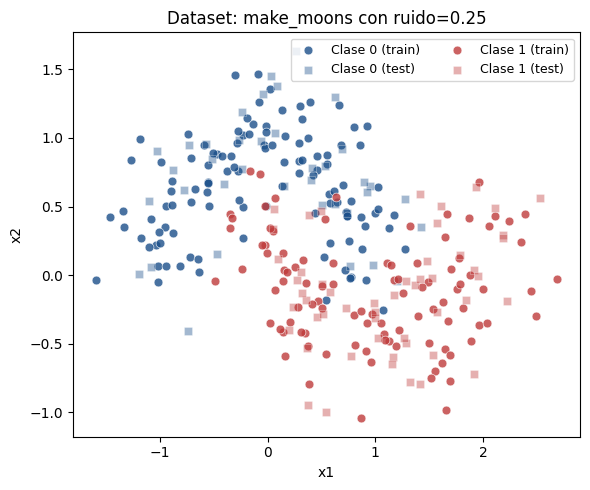

Circulos = train   Cuadrados = test
El patron real f* tiene forma de dos medias lunas entrelazadas.


In [71]:
# Visualizamos el dataset
fig, ax = plt.subplots(figsize=(6, 5))

cmap_pts = ['#1B4F8A', '#BF3B3B']
for clase, color, label in [(0, '#1B4F8A', 'Clase 0'), (1, '#BF3B3B', 'Clase 1')]:
    mask = y_train == clase
    ax.scatter(X_train[mask, 0], X_train[mask, 1],
               c=color, s=40, alpha=0.8, edgecolors='white', lw=0.5, label=f'{label} (train)')
    mask_te = y_test == clase
    ax.scatter(X_test[mask_te, 0], X_test[mask_te, 1],
               c=color, s=40, alpha=0.4, edgecolors='white', lw=0.5,
               marker='s', label=f'{label} (test)')

ax.set_title('Dataset: make_moons con ruido=0.25', fontsize=12)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

print('Circulos = train   Cuadrados = test')
print('El patron real f* tiene forma de dos medias lunas entrelazadas.')

---
## Bloque 2 — Los tres modelos

Usamos `DecisionTreeClassifier` con distintas profundidades.
`max_depth` controla el tamano del espacio de hipotesis H:

| Modelo | max_depth | H | Riesgo esperado |
|---|---|---|---|
| Underfitting | 1 | Muy pequeno — solo un corte | Alto (no captura las lunas) |
| Balance | 4 | Apropiado para este patron | Bajo (captura la forma) |
| Overfitting | sin limite | Enorme — memoriza cada punto | Alto (memorizo el ruido) |

In [72]:
# Entrenamos los tres modelos (h)

#Cada clasificador tiene un paràmetro diferente y creamos el modelo.
# No se ha entrenado
h_under   = DecisionTreeClassifier(max_depth=1, random_state=42)
h_balance = DecisionTreeClassifier(max_depth=4, random_state=42)
h_over    = DecisionTreeClassifier(max_depth=None, random_state=42)  # sin limite


#usando la función fit, entrenamos cada uno de los modelos que fue creado.
#Aquí entrenamos cada uno de los modelos usando el conjunto de entrenamiento
# y la etiqute de clase de entrenamiento
h_under.fit(X_train, y_train)
h_balance.fit(X_train, y_train)
h_over.fit(X_train, y_train)

# Calculamos Loss 0-1 en train y test para cada modelo
modelos = [
    ('Underfitting  (depth=1)',   h_under),
    ('Balance       (depth=4)',   h_balance),
    ('Overfitting   (depth=inf)', h_over),
]

print(f"{'Modelo':<30} {'Loss train':>12} {'Loss test':>12} {'Gap':>10} {'Diagnostico'}")
print('-' * 82)

for nombre, modelo in modelos:
    #Aquí calculamos la pérdida 0-1
    #recibe como entrada el valor de y y el modelo entrenado
    #modelo.predict(X) da como salida el valor y que es la predicción
    l_tr = loss_01(y_train, modelo.predict(X_train))
    l_te = loss_01(y_test,  modelo.predict(X_test))
    gap  = l_te - l_tr   # positivo = overfitting

    print(f'{nombre:<30} {l_tr:>12.3f} {l_te:>12.3f} {gap:>10.3f}')

Modelo                           Loss train    Loss test        Gap Diagnostico
----------------------------------------------------------------------------------
Underfitting  (depth=1)               0.181        0.222      0.041
Balance       (depth=4)               0.100        0.100      0.000
Overfitting   (depth=inf)             0.000        0.078      0.078


---
## Bloque 3 — Visualizacion de las fronteras de decision

La **frontera de decision** es la linea (o curva) que separa las dos clases segun h.

- Frontera recta → modelo simple → H pequeno
- Frontera suave y curva → modelo apropiado → H mediano
- Frontera muy irregular → modelo complejo → H grande (memorizo el ruido)

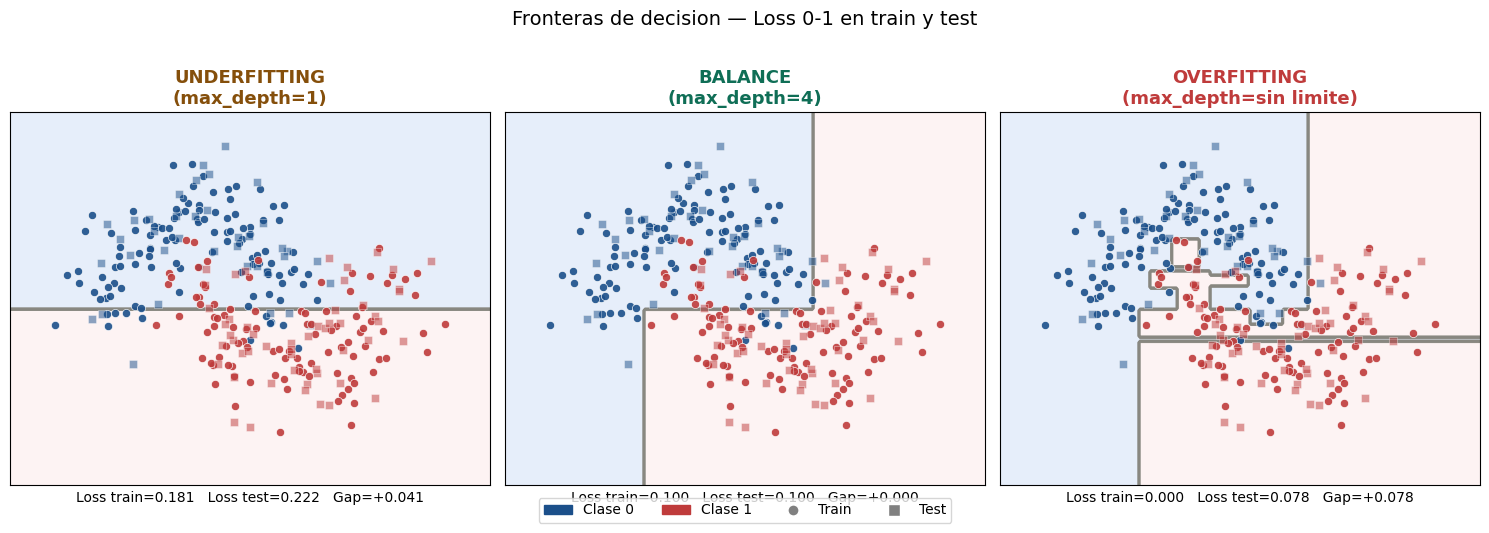

In [73]:
# Funcion para graficar la frontera de decision
from matplotlib.colors import ListedColormap

import matplotlib.patches as mpatches

def plot_frontera(ax, modelo, X_tr, y_tr, X_te, y_te, titulo, color_titulo):
    h = 0.02
    x_min, x_max = X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5
    y_min, y_max = X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_bg = ListedColormap(['#D6E4F7', '#FCEBEB'])
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
    ax.contour( xx, yy, Z, colors=['#888780'], linewidths=1.2, alpha=0.8)

    for clase, color in [(0, '#1B4F8A'), (1, '#BF3B3B')]:
        m_tr = y_tr == clase
        ax.scatter(X_tr[m_tr, 0], X_tr[m_tr, 1], c=color, s=35,
                   edgecolors='white', lw=0.5, alpha=0.9, zorder=3)
        m_te = y_te == clase
        ax.scatter(X_te[m_te, 0], X_te[m_te, 1], c=color, s=35,
                   marker='s', edgecolors='white', lw=0.5, alpha=0.5, zorder=3)

    # Loss 0-1
    l_tr = loss_01(y_tr, modelo.predict(X_tr))
    l_te = loss_01(y_te, modelo.predict(X_te))
    gap  = l_te - l_tr

    ax.set_title(titulo, fontsize=13, color=color_titulo, fontweight='bold')
    ax.set_xlabel(
        f'Loss train={l_tr:.3f}   Loss test={l_te:.3f}   Gap={gap:+.3f}',
        fontsize=10
    )
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_frontera(axes[0], h_under,   X_train, y_train, X_test, y_test,
              'UNDERFITTING\n(max_depth=1)', '#854F0B')
plot_frontera(axes[1], h_balance, X_train, y_train, X_test, y_test,
              'BALANCE\n(max_depth=4)', '#0F6E56')
plot_frontera(axes[2], h_over,    X_train, y_train, X_test, y_test,
              'OVERFITTING\n(max_depth=sin limite)', '#BF3B3B')

# Leyenda comun
p0  = mpatches.Patch(color='#1B4F8A', label='Clase 0')
p1  = mpatches.Patch(color='#BF3B3B', label='Clase 1')
ptr = plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
                 markersize=8, label='Train')
pte = plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray',
                 markersize=8, label='Test')
fig.legend(handles=[p0, p1, ptr, pte], loc='lower center',
           ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Fronteras de decision — Loss 0-1 en train y test', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Bloque 4 — La curva de complejidad

Variamos `max_depth` de 1 a 20 y graficamos el Loss 0-1 en train y en test.

La curva muestra el **tradeoff sesgo-varianza** en un solo grafico:

- **Izquierda:** loss train Y test altos → underfitting
- **Centro:** loss test en su minimo → balance optimo
- **Derecha:** loss train baja, loss test sube → overfitting

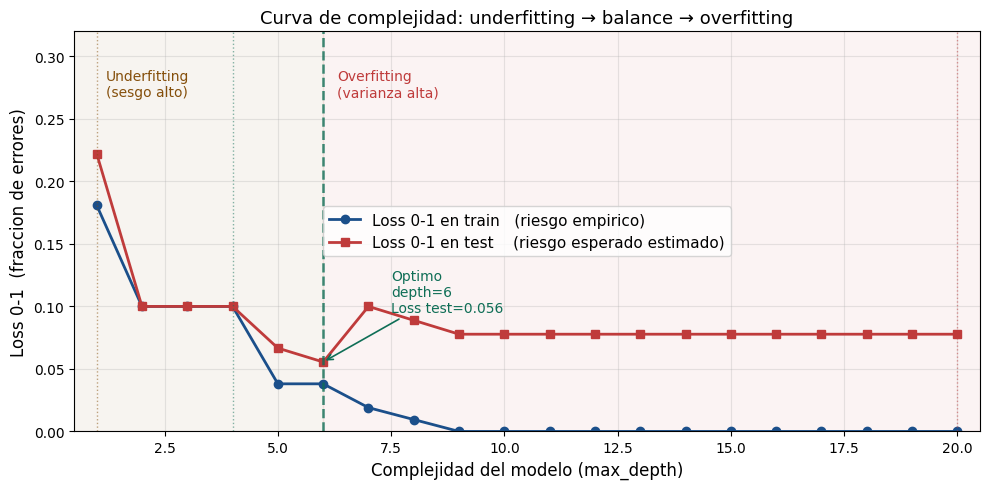

In [74]:
# Curva de complejidad
#Aquí defino una lista de parámetros a usar en Decision Tree
profundidades = list(range(1, 21))
loss_trains, loss_tests = [], []

#En este ciclo se entrenan y evalúan los modelos de decisión con tree
# con distintos parámetros en la profundidad.
for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_train, y_train)
    loss_trains.append(loss_01(y_train, modelo.predict(X_train)))
    loss_tests.append( loss_01(y_test,  modelo.predict(X_test)))

idx_opt   = int(np.argmin(loss_tests))
depth_opt = profundidades[idx_opt]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(profundidades, loss_trains, 'o-', color='#1B4F8A',
        lw=2, ms=6, label='Loss 0-1 en train   (riesgo empirico)')
ax.plot(profundidades, loss_tests,  's-', color='#BF3B3B',
        lw=2, ms=6, label='Loss 0-1 en test    (riesgo esperado estimado)')

# Punto optimo
ax.axvline(depth_opt, color='#0F6E56', lw=1.8, ls='--', alpha=0.8)
ax.annotate(
    f'Optimo\ndepth={depth_opt}\nLoss test={loss_tests[idx_opt]:.3f}',
    xy=(depth_opt, loss_tests[idx_opt]),
    xytext=(depth_opt + 1.5, loss_tests[idx_opt] + 0.04),
    fontsize=10, color='#0F6E56',
    arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=1.2)
)

# Zonas de color
ax.axvspan(0.5, depth_opt,   alpha=0.06, color='#854F0B')
ax.axvspan(depth_opt, 20.5,  alpha=0.06, color='#BF3B3B')

ax.text(1.2,  0.29, 'Underfitting\n(sesgo alto)',  fontsize=10, color='#854F0B', va='top')
ax.text(depth_opt + 0.3, 0.29, 'Overfitting\n(varianza alta)', fontsize=10, color='#BF3B3B', va='top')

# Marcar los tres casos del Bloque 2
for d, label, col in [(1, 'Depth=1\n(under)', '#854F0B'),
                       (4, 'Depth=4\n(balance)', '#0F6E56'),
                       (20,'Depth=20\n(over)', '#BF3B3B')]:
    y_val = loss_tests[d - 1]
    ax.axvline(d, color=col, lw=1, ls=':', alpha=0.5)

ax.set_xlabel('Complejidad del modelo (max_depth)', fontsize=12)
ax.set_ylabel('Loss 0-1  (fraccion de errores)', fontsize=12)
ax.set_title('Curva de complejidad: underfitting → balance → overfitting', fontsize=13)
ax.set_xlim(0.5, 20.5)
ax.set_ylim(0, 0.32)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Funciones compartidas para los dos ejercicios

##Función para creación del dataset seccionado

In [75]:
import numpy as np
# Generamos el dataset
np.random.seed(42)

def create_split_moons_dataset(param_noise):
  #X tiene el conjunto de datos de M x N
  #Y es el vector de clases
  X, y = make_moons(n_samples=300, noise=param_noise, random_state=42)

  # Split 70 / 30
  # 70% datos de Entrenamiento
  # 30% Datos de test
  #Devuelve 4 archivos: 2 del conjunto de datos en entrenamiento y test,
  # y otros 2 con las etiquetas de clase de entrenamiento y test
  # con Random_state agregarmos una semilla
  # Estratificamos para cumplir con las probabilidades a priori en entrenamiento y test
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.30, random_state=42
  )

  print(f'Train: {X_train.shape[0]} ejemplos')
  print(f'Test:  {X_test.shape[0]} ejemplos')
  print(f'Clases: {np.bincount(y_train)} en train   {np.bincount(y_test)} en test')

  # Return the datasets as a dictionary
  return {'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test}

##Función para desplegar datos de entrada

In [76]:
import matplotlib.pyplot as plt
# Visualizamos el dataset
def display_scatter(param_x_train,param_x_test,param_y_train,param_y_test,param_noise):
  fig, ax = plt.subplots(figsize=(6, 5))

  cmap_pts = ['#1B4F8A', '#BF3B3B']
  for clase, color, label in [(0, '#1B4F8A', 'Clase 0'), (1, '#BF3B3B', 'Clase 1')]:
      mask = param_y_train == clase
      ax.scatter(param_x_train[mask, 0], param_x_train[mask, 1],
                c=color, s=40, alpha=0.8, edgecolors='white', lw=0.5, label=f'{label} (train)')
      mask_te = param_y_test == clase
      ax.scatter(param_x_test[mask_te, 0], param_x_test[mask_te, 1],
                c=color, s=40, alpha=0.4, edgecolors='white', lw=0.5,
                marker='s', label=f'{label} (test)')

  dataset_title = f"Dataset: make_moons con ruido={param_noise:.2f}"
  ax.set_title(dataset_title, fontsize=12)
  ax.set_xlabel('x1')
  ax.set_ylabel('x2')
  ax.legend(fontsize=9, ncol=2)
  plt.tight_layout()
  plt.show()

  print('Circulos = train   Cuadrados = test')
  print('El patron real f* tiene forma de dos medias lunas entrelazadas.')



## Función para calcular y graficar

In [77]:
# Curva de complejidad
def plot_complexity_curve(param_dataset, param_max_depth=21):
  #Aquí defino una lista de parámetros a usar en Decision Tree
  profundidades = list(range(1, param_max_depth))
  loss_trains, loss_tests = [], []

  #En este ciclo se entrenan y evalúan los modelos de decisión con tree
  # con distintos parámetros en la profundidad.
  for d in profundidades:
      modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
      modelo.fit(param_dataset['X_train'], param_dataset['y_train'])
      loss_trains.append(loss_01(param_dataset['y_train'], modelo.predict(param_dataset['X_train'])))
      loss_tests.append( loss_01(param_dataset['y_test'],  modelo.predict(param_dataset['X_test'])))

  idx_opt   = int(np.argmin(loss_tests))
  depth_opt = profundidades[idx_opt]

  fig, ax = plt.subplots(figsize=(10, 5))

  ax.plot(profundidades, loss_trains, 'o-', color='#1B4F8A',
          lw=2, ms=6, label='Loss 0-1 en train   (riesgo empirico)')
  ax.plot(profundidades, loss_tests,  's-', color='#BF3B3B',
          lw=2, ms=6, label='Loss 0-1 en test    (riesgo esperado estimado)')

  # Punto optimo
  ax.axvline(depth_opt, color='#0F6E56', lw=1.8, ls='--', alpha=0.8)
  ax.annotate(
      f'Optimo\ndepth={depth_opt}\nLoss test={loss_tests[idx_opt]:.3f}',
      xy=(depth_opt, loss_tests[idx_opt]),
      xytext=(depth_opt + 1.5, loss_tests[idx_opt] + 0.04),
      fontsize=10, color='#0F6E56',
      arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=1.2)
  )

  # Zonas de color
  ax.axvspan(0.5, depth_opt,   alpha=0.06, color='#854F0B')
  ax.axvspan(depth_opt, 20.5,  alpha=0.06, color='#BF3B3B')

  ax.text(1.2,  0.29, 'Underfitting\n(sesgo alto)',  fontsize=10, color='#854F0B', va='top')
  ax.text(depth_opt + 0.3, 0.29, 'Overfitting\n(varianza alta)', fontsize=10, color='#BF3B3B', va='top')

  # Marcar los tres casos del Bloque 2
  for d, label, col in [(1, 'Depth=1\n(under)', '#854F0B'),
                        (4, 'Depth=4\n(balance)', '#0F6E56'),
                        (20,'Depth=20\n(over)', '#BF3B3B')]:
      y_val = loss_tests[d - 1]
      ax.axvline(d, color=col, lw=1, ls=':', alpha=0.5)

  ax.set_xlabel('Complejidad del modelo (max_depth)', fontsize=12)
  ax.set_ylabel('Loss 0-1  (fraccion de errores)', fontsize=12)
  ax.set_title('Curva de complejidad: underfitting → balance → overfitting', fontsize=13)
  ax.set_xlim(0.5, 20.5)
  ax.set_ylim(0, 0.32)
  ax.legend(fontsize=11)
  ax.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()


#Ejercicio 1
1. Cambia los parámetros del conjunto de datos moon, en específico el ruido del dataset a noise =0.05
2. Al igual que en cuaderno de práctica, dibuja las curvas de complejidad usando max_depth de 1 a 20
3. En qué valores de max_depth se observa un overfitting y un underfitting


---
## Ejercicio 1 — La curva de complejidad

Variamos `max_depth` de 1 a 20 y graficamos el Loss 0-1 en train y en test.

La curva muestra el **tradeoff sesgo-varianza** en un solo grafico:

- **max_depth<5:** loss train Y test altos → underfitting
- **max_depth=5:** loss test en su minimo → balance optimo
- **max_depth>5:** loss train baja, loss test sube → overfitting

In [78]:
# create the dedicated dataset with noise=0.05
split_moons_dataset_05 = create_split_moons_dataset(0.05)

Train: 210 ejemplos
Test:  90 ejemplos
Clases: [112  98] en train   [38 52] en test


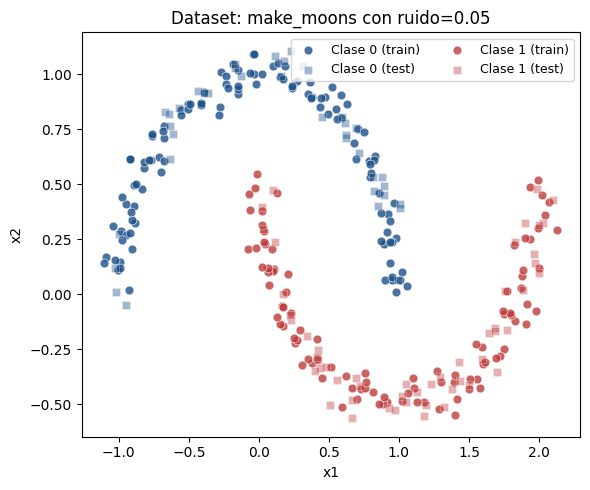

Circulos = train   Cuadrados = test
El patron real f* tiene forma de dos medias lunas entrelazadas.


In [79]:
#plot the dataset for both training and testing segregated by class
display_scatter(
    split_moons_dataset_05['X_train'],
    split_moons_dataset_05['X_test'],
    split_moons_dataset_05['y_train'],
    split_moons_dataset_05['y_test'],
    0.05
);

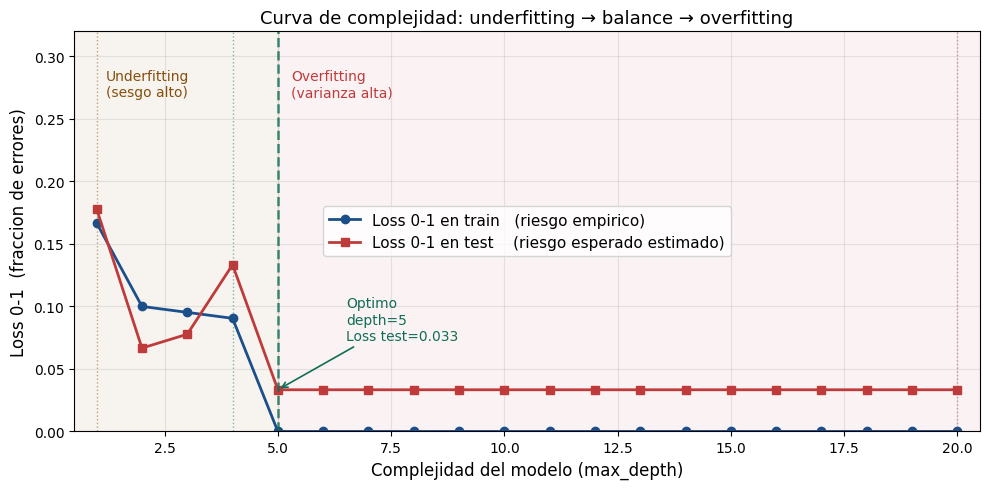

In [80]:
# plot the complexity curve for noise = 0.05
plot_complexity_curve(split_moons_dataset_05)

#Ejercicio 2
4. Cambia los parámetros del conjunto de datos moon, en específico el ruido del dataset a noise =0.40
5. Al igual que en cuaderno de práctica, dibuja las curvas de complejidad usando max_depth de 1 a 20
6. En qué valores de max_depth se observa un overfitting y un underfitting




---
## Ejercicio 2 — La curva de complejidad

Variamos `max_depth` de 1 a 20 y graficamos el Loss 0-1 en train y en test.

La curva muestra el **tradeoff sesgo-varianza** en un solo grafico:

- **max_depth<2:** loss train Y test altos → underfitting
- **max_depth=2:** loss test en su minimo → balance optimo
- **max_depth>2:** loss train baja, loss test sube → overfitting

In [81]:
# create the dedicated dataset with noise=0.40
split_moons_dataset_40 = create_split_moons_dataset(0.40)

Train: 210 ejemplos
Test:  90 ejemplos
Clases: [112  98] en train   [38 52] en test


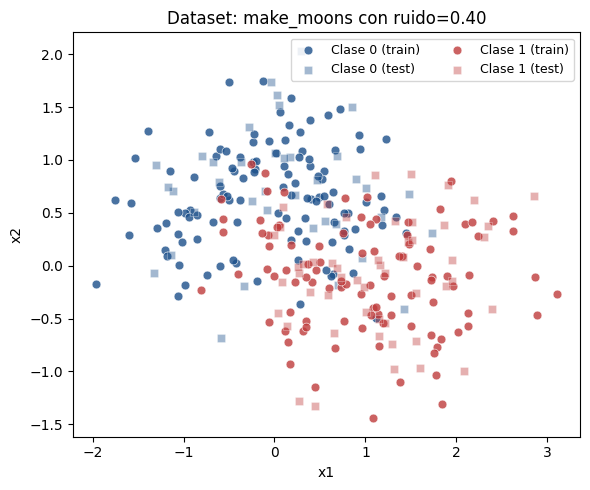

Circulos = train   Cuadrados = test
El patron real f* tiene forma de dos medias lunas entrelazadas.


In [84]:
#plot the dataset for both training and testing segregated by class
display_scatter(
    split_moons_dataset_40['X_train'],
    split_moons_dataset_40['X_test'],
    split_moons_dataset_40['y_train'],
    split_moons_dataset_40['y_test'],
    0.40
);

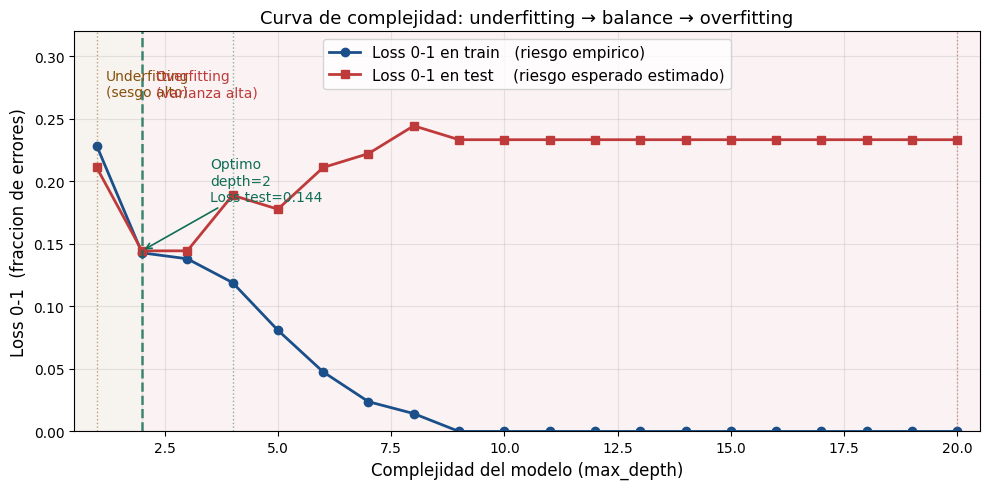

In [83]:
# plot the complexity curve for noise = 0.40
plot_complexity_curve(split_moons_dataset_40)

#Conclusiones
Con la utilización de la función ``make_moons`` para crear conjuntos de datos de prueba y el algoritmo ``DecisionTreeClassifier``, a medida que aumenta el ruido en la creación de el conjunto de datos de entrada, la complejidad requerida del modelo a entrenar aumenta.

De esa forma, con solo 5% de ruido al crear el conjunto de datos,el gráfico de dispersión muestra una separación clara de las clases y a su vez el modelo logra una predicción óptima y estable con 5 niveles.

Con 25% de ruido se logra optimizar con 6 niveles aunque asume una perdida mayor en las predicciones sobre los datos de pruebas.

Por su parte, cuando el ruido es del 40%, las clases muestran una sobreposición muy alta y la optimización del modelo se logra mas rápido pero permanece con resultados altos en la función de pérdida tanto en datos de entrenamiento, como de pruebas.